# Izaz Khan  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** DIP Lab 06

***Date:*** 27/04/2026

##  Install / Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
# Scenario 01: Histogram Processing for Medical Imaging

**Goal:** Analyze the intensity distribution of a medical image (e.g., an X-ray) to identify underexposed or overexposed regions, then enhance the image accordingly.

### Tasks:
1. Load a medical image and plot its histogram.
2. Identify whether the image is underexposed, overexposed, or well-balanced.
3. Enhance the image using intensity stretching based on histogram characteristics.

In [2]:
# ─── TASK 1 & 2: Upload Medical Image & Plot Histogram ───────────────────────

print('Please upload your MEDICAL IMAGE (e.g., X-ray):')
uploaded = files.upload()

# Load the uploaded image
medical_filename = list(uploaded.keys())[0]
medical_img = cv2.imread(medical_filename, cv2.IMREAD_GRAYSCALE)

if medical_img is None:
    raise ValueError(f'Could not read image: {medical_filename}. Make sure it is a valid image file.')

print(f'Image loaded: {medical_filename}  |  Shape: {medical_img.shape}')

Please upload your MEDICAL IMAGE (e.g., X-ray):


Saving 1.jpg to 1.jpg
Image loaded: 1.jpg  |  Shape: (148, 209)


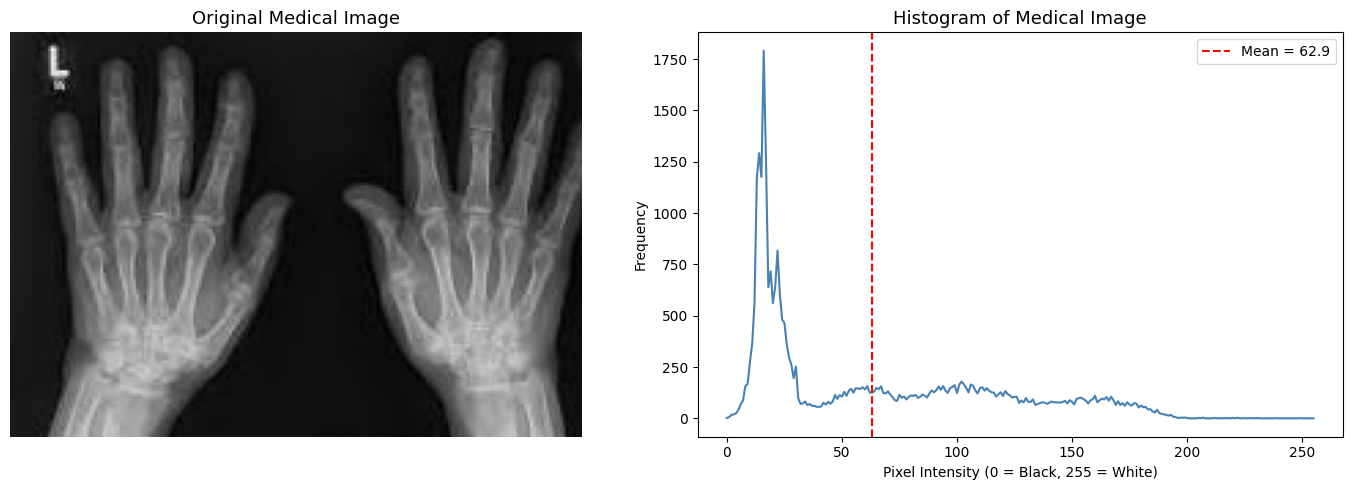

Figure saved as s1_original_and_histogram.png


In [3]:
# ─── Plot Original Image + Histogram ─────────────────────────────────────────

hist = cv2.calcHist([medical_img], [0], None, [256], [0, 256]).flatten()
mean_intensity = np.mean(medical_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(medical_img, cmap='gray')
axes[0].set_title('Original Medical Image', fontsize=13)
axes[0].axis('off')

axes[1].plot(hist, color='steelblue')
axes[1].set_title('Histogram of Medical Image', fontsize=13)
axes[1].set_xlabel('Pixel Intensity (0 = Black, 255 = White)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(mean_intensity, color='red', linestyle='--', label=f'Mean = {mean_intensity:.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('s1_original_and_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s1_original_and_histogram.png')

In [4]:
# ─── TASK 2: Identify Exposure Type ──────────────────────────────────────────

def classify_exposure(image):
    """Classify image as underexposed, overexposed, or well-balanced."""
    mean_val = np.mean(image)
    if mean_val < 85:
        status = 'UNDEREXPOSED (dark image – mean intensity too low)'
    elif mean_val > 170:
        status = 'OVEREXPOSED (bright image – mean intensity too high)'
    else:
        status = 'WELL-BALANCED (good exposure)'
    return mean_val, status

mean_val, status = classify_exposure(medical_img)
print('=' * 55)
print(f'  Mean Pixel Intensity : {mean_val:.2f} / 255')
print(f'  Diagnosis            : {status}')
print('=' * 55)

  Mean Pixel Intensity : 62.94 / 255
  Diagnosis            : UNDEREXPOSED (dark image – mean intensity too low)


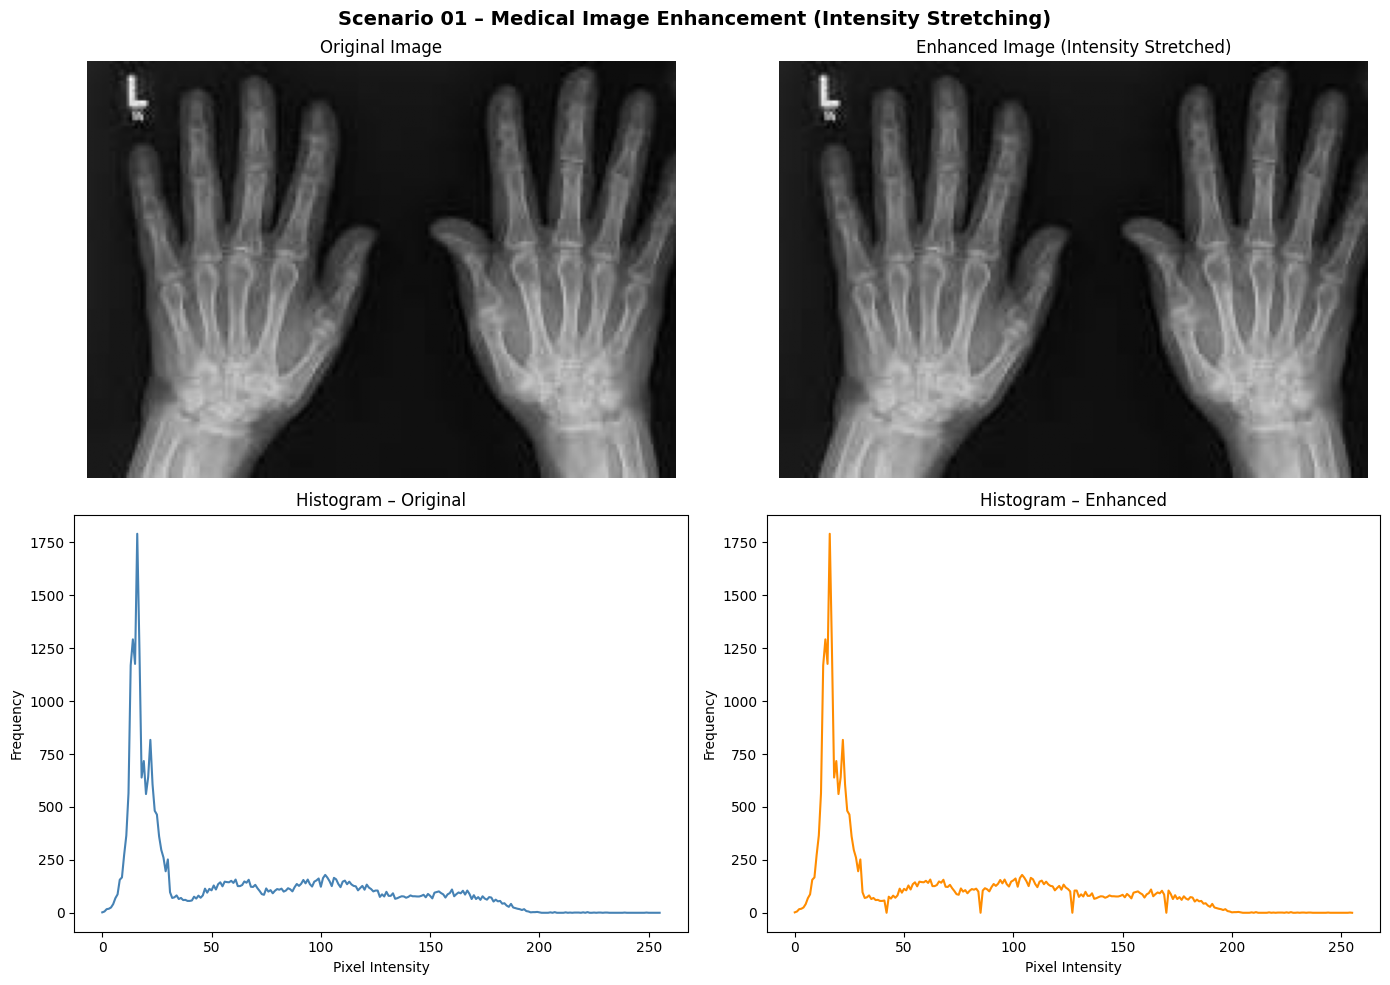

Figure saved as s1_enhancement_result.png


In [5]:
# ─── TASK 3: Enhance via Intensity Stretching ─────────────────────────────────

def enhance_by_stretching(image):
    """
    Stretch pixel values from [min, max] → [0, 255].
    This maximises the dynamic range without clipping.
    """
    img_min = image.min()
    img_max = image.max()
    stretched = ((image.astype(np.float32) - img_min) /
                 (img_max - img_min + 1e-6) * 255).astype(np.uint8)
    return stretched

enhanced_medical = enhance_by_stretching(medical_img)

hist_orig     = cv2.calcHist([medical_img],    [0], None, [256], [0, 256]).flatten()
hist_enhanced = cv2.calcHist([enhanced_medical],[0], None, [256], [0, 256]).flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(medical_img,    cmap='gray'); axes[0, 0].set_title('Original Image');  axes[0, 0].axis('off')
axes[0, 1].imshow(enhanced_medical,cmap='gray'); axes[0, 1].set_title('Enhanced Image (Intensity Stretched)'); axes[0, 1].axis('off')
axes[1, 0].plot(hist_orig,     color='steelblue'); axes[1, 0].set_title('Histogram – Original');  axes[1, 0].set_xlabel('Pixel Intensity'); axes[1, 0].set_ylabel('Frequency')
axes[1, 1].plot(hist_enhanced, color='darkorange'); axes[1, 1].set_title('Histogram – Enhanced'); axes[1, 1].set_xlabel('Pixel Intensity'); axes[1, 1].set_ylabel('Frequency')

plt.suptitle('Scenario 01 – Medical Image Enhancement (Intensity Stretching)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('s1_enhancement_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s1_enhancement_result.png')

---
#  Scenario 02: Global Histogram Equalization for Satellite Imaging

**Goal:** Satellite images suffer from poor contrast due to atmospheric haze. Apply global histogram equalization to improve contrast uniformly across the entire image.

### Tasks:
1. Load a satellite image.
2. Apply global histogram equalization.
3. Compare the original and equalized images side by side.

In [6]:
# ─── TASK 1: Upload Satellite Image ──────────────────────────────────────────

print('Please upload your SATELLITE IMAGE:')
uploaded2 = files.upload()

satellite_filename = list(uploaded2.keys())[0]
satellite_img = cv2.imread(satellite_filename, cv2.IMREAD_GRAYSCALE)

if satellite_img is None:
    raise ValueError(f'Could not read image: {satellite_filename}')

print(f'Image loaded: {satellite_filename}  |  Shape: {satellite_img.shape}')

Please upload your SATELLITE IMAGE:


Saving 2.jpg to 2.jpg
Image loaded: 2.jpg  |  Shape: (218, 231)


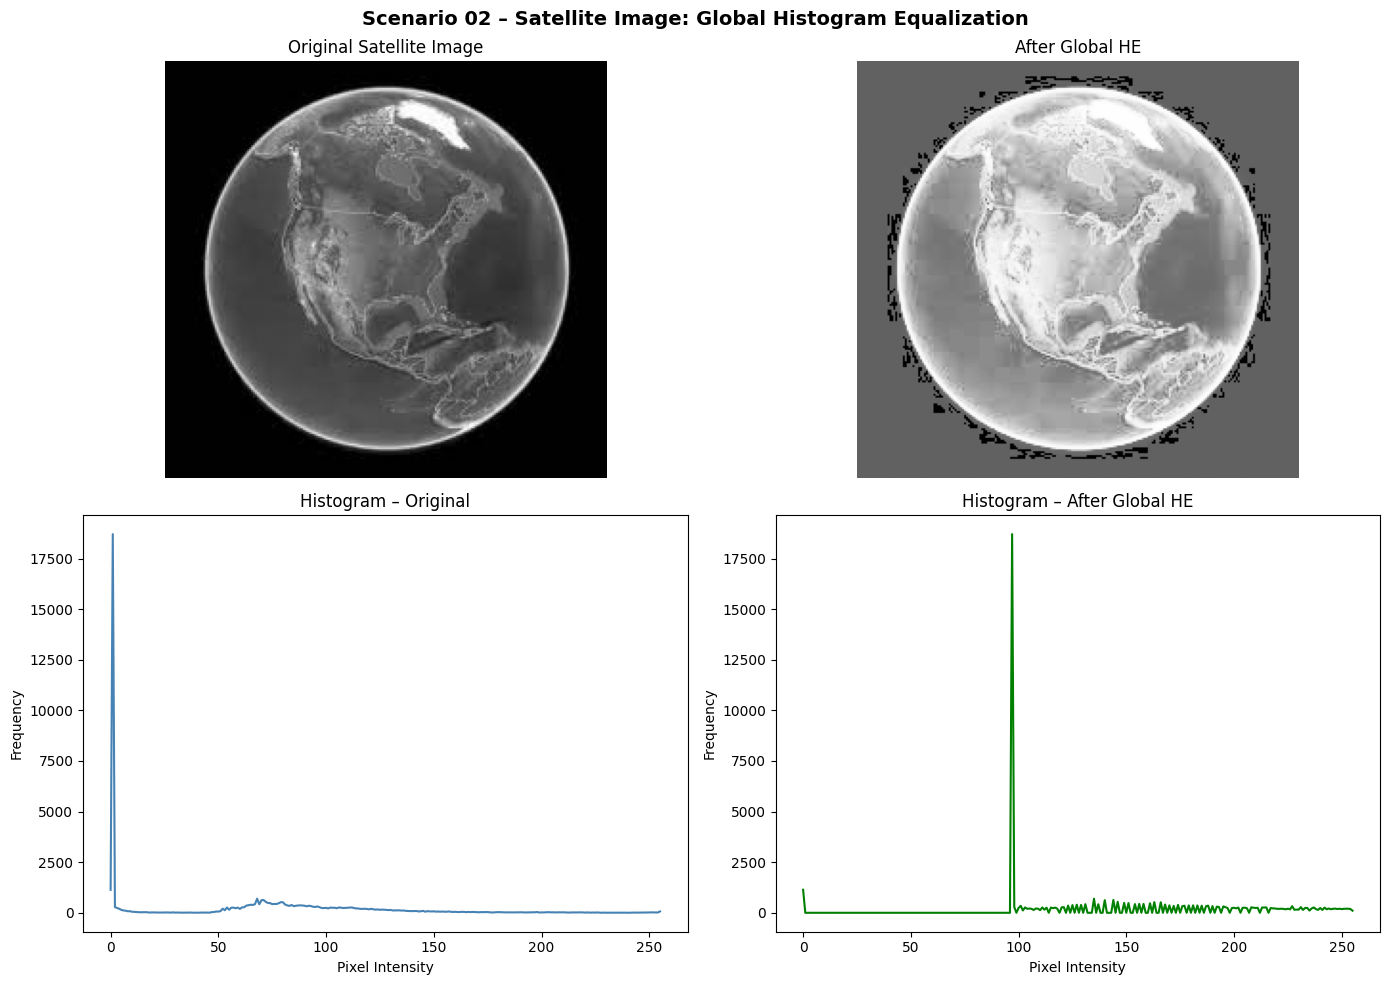

Figure saved as s2_global_he_result.png


In [7]:
# ─── TASK 2 & 3: Apply Global HE & Compare ───────────────────────────────────

# Apply OpenCV's built-in global histogram equalization
equalized_satellite = cv2.equalizeHist(satellite_img)

hist_sat_orig = cv2.calcHist([satellite_img],     [0], None, [256], [0, 256]).flatten()
hist_sat_eq   = cv2.calcHist([equalized_satellite],[0], None, [256], [0, 256]).flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(satellite_img,     cmap='gray'); axes[0, 0].set_title('Original Satellite Image');   axes[0, 0].axis('off')
axes[0, 1].imshow(equalized_satellite,cmap='gray'); axes[0, 1].set_title('After Global HE');           axes[0, 1].axis('off')
axes[1, 0].plot(hist_sat_orig, color='steelblue');  axes[1, 0].set_title('Histogram – Original');      axes[1, 0].set_xlabel('Pixel Intensity'); axes[1, 0].set_ylabel('Frequency')
axes[1, 1].plot(hist_sat_eq,  color='green');       axes[1, 1].set_title('Histogram – After Global HE'); axes[1, 1].set_xlabel('Pixel Intensity'); axes[1, 1].set_ylabel('Frequency')

plt.suptitle('Scenario 02 – Satellite Image: Global Histogram Equalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('s2_global_he_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s2_global_he_result.png')

---
#  Scenario 03: Local Histogram Equalization (CLAHE) for Wildlife Photography

**Goal:** Wildlife images taken in uneven lighting have dark and bright patches. CLAHE (Contrast Limited Adaptive Histogram Equalization) divides the image into tiles and equalizes each locally, preserving natural appearance while boosting local contrast.

### Tasks:
1. Load a wildlife image.
2. Apply CLAHE with appropriate `clipLimit` and `tileGridSize`.
3. Compare original and enhanced images.

In [8]:
# ─── TASK 1: Upload Wildlife Image ───────────────────────────────────────────

print('Please upload your WILDLIFE IMAGE:')
uploaded3 = files.upload()

wildlife_filename = list(uploaded3.keys())[0]
wildlife_img = cv2.imread(wildlife_filename, cv2.IMREAD_GRAYSCALE)

if wildlife_img is None:
    raise ValueError(f'Could not read image: {wildlife_filename}')

print(f'Image loaded: {wildlife_filename}  |  Shape: {wildlife_img.shape}')

Please upload your WILDLIFE IMAGE:


Saving 3.jpg to 3.jpg
Image loaded: 3.jpg  |  Shape: (161, 312)


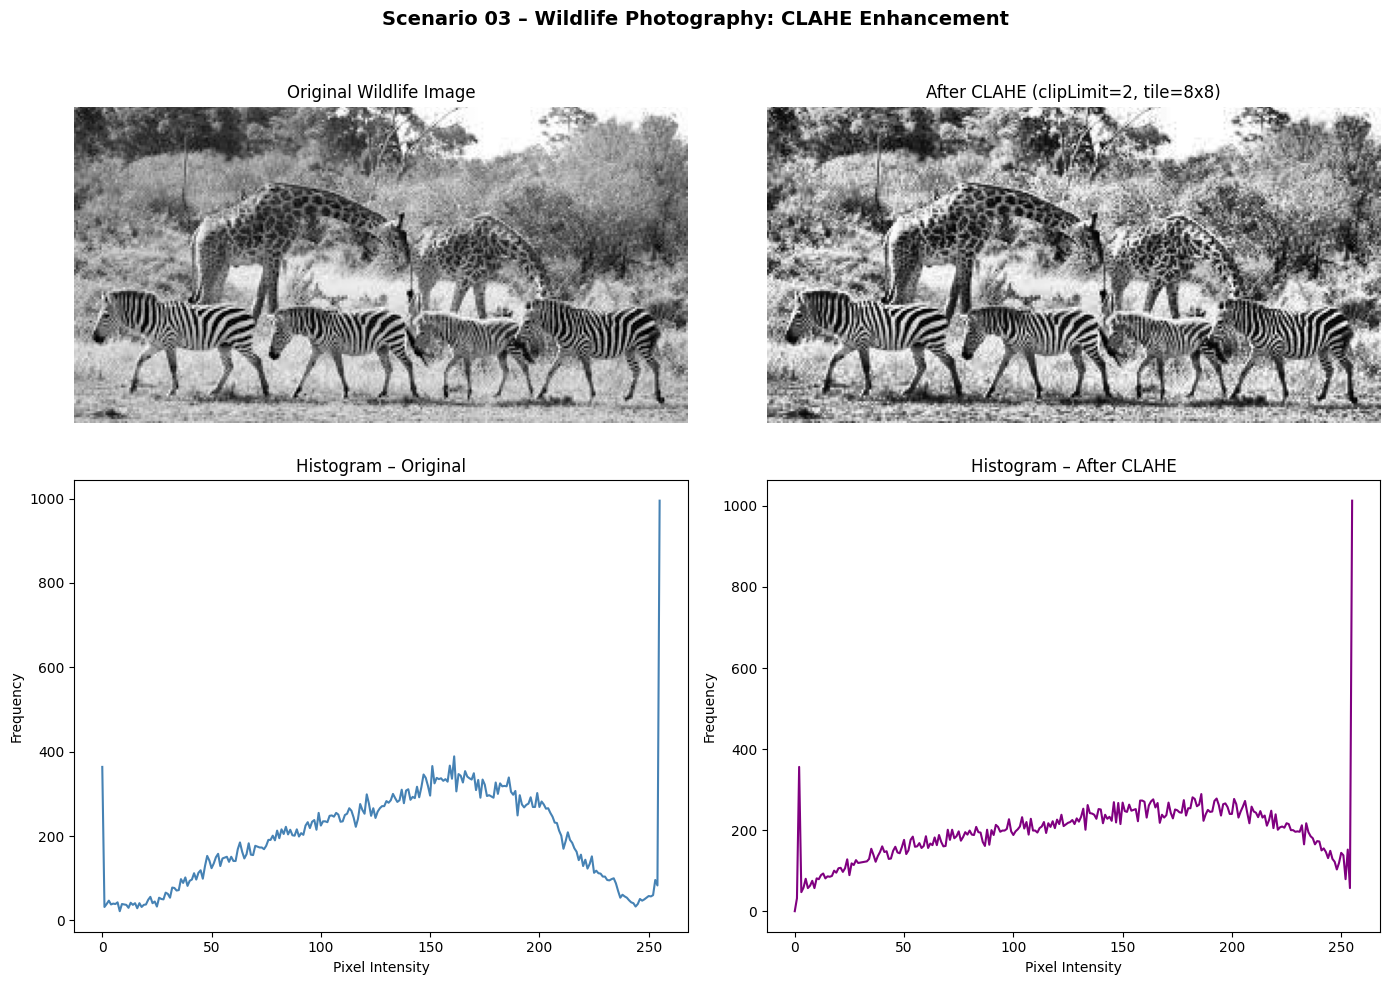

Figure saved as s3_clahe_result.png


In [9]:
# ─── TASK 2 & 3: Apply CLAHE & Compare ───────────────────────────────────────

# CLAHE Parameters:
#   clipLimit   – threshold for contrast limiting (2.0 is a safe default)
#   tileGridSize – size of tiles the image is divided into (8x8 is standard)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_result = clahe.apply(wildlife_img)

hist_wild_orig  = cv2.calcHist([wildlife_img], [0], None, [256], [0, 256]).flatten()
hist_wild_clahe = cv2.calcHist([clahe_result], [0], None, [256], [0, 256]).flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(wildlife_img, cmap='gray');  axes[0, 0].set_title('Original Wildlife Image');         axes[0, 0].axis('off')
axes[0, 1].imshow(clahe_result, cmap='gray');  axes[0, 1].set_title('After CLAHE (clipLimit=2, tile=8x8)'); axes[0, 1].axis('off')
axes[1, 0].plot(hist_wild_orig,  color='steelblue');  axes[1, 0].set_title('Histogram – Original');     axes[1, 0].set_xlabel('Pixel Intensity'); axes[1, 0].set_ylabel('Frequency')
axes[1, 1].plot(hist_wild_clahe, color='purple');     axes[1, 1].set_title('Histogram – After CLAHE');  axes[1, 1].set_xlabel('Pixel Intensity'); axes[1, 1].set_ylabel('Frequency')

plt.suptitle('Scenario 03 – Wildlife Photography: CLAHE Enhancement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('s3_clahe_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as s3_clahe_result.png')